## IND320- Project work, part 1 - Dashboard basics

1. Project links

Repo: https://github.com/Andreolesen/AndreOlesen-IND320  
Streamlit: https://andreolesen-ind320.streamlit.app/

2. AI Usage

I used Claude as a sparring partner throughout this part of the project, mainly to get clarity on things I was unsure about and to talk through design choices before implementing them. It suggested what to look for when first exploring reservoirs.csv like checking omrType/omrnr for mixed regions before trusting the data as one time series, and it was Claude's suggestion to min-max normalise the columns to compare their shapes on one plot, given the different scales and units. It also helped me think through how to structure the code to avoid duplicating work between the notebook and the Streamlit app, which led to pulling the cleaning logic into a shared data_utils.py module used by both. Claude also helped me keep a running log of what I had built as I went, and drafted a first version of the log below, which I reviewed and edited myself.

3. Log

For this part of the project, I worked through the Jupyter Notebook and the Streamlit app in parallel, using the notebook to explore and document the analysis, and the app to turn the same logic into an interactive tool.

I started by loading reservoirs.csv directly to see its structure, and quickly found that the file mixes several geographical breakdowns on the same dates: the omrType column takes the values EL (5 electricity price areas), NO (a single national total), and VASS (3 watershed regions), so the raw file has multiple rows per date rather than one time series. Plotting it as-is would have mixed all of these together, so I filtered to the national total (omrType == "NO", omrnr == 0) before doing anything else, which gives one clean weekly series. I also renamed the original Norwegian column names to clearer English ones (fill_ratio, capacity_TWh, fill_TWh, fill_ratio_previous_week, fill_ratio_change) and dropped columns that became redundant or constant after filtering, such as omrType/omrnr themselves and the ISO week/year columns, plus neste_Publiseringsdato, which is publication-schedule metadata rather than reservoir data (and contains an unparseable placeholder date for older rows).

For the plots, the columns are on very different scales. fill_ratio and fill_ratio_previous_week are fractions between 0 and 1, capacity_TWh and fill_TWh are tens of TWh, and fill_ratio_change is a small week-to-week delta, so plotting them together directly would make the smaller-scale columns almost invisible. I first plotted each column separately in its own subplot to see the real values and units, then built a second, min-max normalised plot to compare the shapes of all series on one axis. capacity_TWh turned out to be essentially constant at the national level, so I excluded it from the normalised plot since normalising a near-constant column mostly divides by zero and adds no useful comparison.

On the Streamlit side, I reused the same cleaning logic in a cached load_reservoir_data() function so the CSV is only read and processed once per session. The app currently has four pages: a home page, a data table page showing one row per column with a LineChartColumn sparkline for the first month, a plot page with a dropdown to choose a single column or all columns and a select slider to pick a range of months (defaulting to the first month), and a placeholder fourth page for later parts of the project.

The most useful thing I learned was how much a single messy source file can hide.The csv would have produced a meaningless plot if I hadn't checked the unique values and row counts per group first. Getting the normalisation logic right for the combined plot, and deciding what to do about the constant capacity_TWh column, also took a bit of trial and error.

4. Imports

In [10]:
import matplotlib.pyplot as plt
import pandas as pd


5. Reading and understanding the data

In [ ]:

# Read the raw reservoir data
df = pd.read_csv("data/reservoirs.csv")

# Quick look at the data
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [ ]:
df.info() # Get information about the DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  str    
 1   omrType                   14877 non-null  str    
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


In [ ]:
df["omrType"].unique() # Get unique values in the "omrType" column

<ArrowStringArray>
['EL', 'NO', 'VASS']
Length: 3, dtype: str

In [ ]:
df.groupby(["omrType", "omrnr"]).size() # Count the number of occurrences for each combination of "omrType" and "omrnr"

omrType  omrnr
EL       1        1653
         2        1653
         3        1653
         4        1653
         5        1653
NO       0        1653
VASS     1        1653
         2        1653
         3        1653
dtype: int64

6. Filtering to a single series

In [ ]:
"""
Keep only the national total ("NO", region 0) so we get one clean
 weekly time series, instead of mixing 9 different regions on the same dates.
"""
df_national = df[(df["omrType"] == "NO") & (df["omrnr"] == 0)].copy()

# Sort the DataFrame by date.
df_national["dato_Id"] = pd.to_datetime(df_national["dato_Id"])
df_national = df_national.sort_values("dato_Id").reset_index(drop=True)

print(f"Rows after filtering: {len(df_national)}")
df_national.head()

Rows after filtering: 1653


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-01-08,NO,0,1995,1,0.608274,87.43758,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
1,1995-01-15,NO,0,1995,2,0.582372,87.43758,50.921207,0001-01-01T00:00:00,0.608274,-0.025902
2,1995-01-22,NO,0,1995,3,0.562412,87.43758,49.175980,0001-01-01T00:00:00,0.582390,-0.019977
3,1995-01-29,NO,0,1995,4,0.534508,87.43758,46.736122,0001-01-01T00:00:00,0.562412,-0.027904
4,1995-02-05,NO,0,1995,5,0.506486,87.43758,44.285900,0001-01-01T00:00:00,0.534489,-0.028003


## 7. Renaming Columns



In [6]:
# Rename to english names.
df_national = df_national.rename(columns={
    "dato_Id": "date",
    "fyllingsgrad": "fill_ratio",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "fill_TWh",
    "fyllingsgrad_forrige_uke": "fill_ratio_previous_week",
    "endring_fyllingsgrad": "fill_ratio_change",
})

df_national.head()

,date,omrType,omrnr,iso_aar,iso_uke,fill_ratio,capacity_TWh,fill_TWh,neste_Publiseringsdato,fill_ratio_previous_week,fill_ratio_change
0,1995-01-08,NO,0,1995,1,0.608274,87.43758,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
1,1995-01-15,NO,0,1995,2,0.582372,87.43758,50.921207,0001-01-01T00:00:00,0.608274,-0.025902
2,1995-01-22,NO,0,1995,3,0.562412,87.43758,49.175980,0001-01-01T00:00:00,0.582390,-0.019977
3,1995-01-29,NO,0,1995,4,0.534508,87.43758,46.736122,0001-01-01T00:00:00,0.562412,-0.027904
4,1995-02-05,NO,0,1995,5,0.506486,87.43758,44.285900,0001-01-01T00:00:00,0.534489,-0.028003


8. Selecting the data columns

The original file contains three region breakdowns for the same dates (5 electricity
price areas, 1 national total, 3 watershed groups) — see the exploration above. We
filtered to the national total (`omrType == "NO"`, `omrnr == 0`) to get a single,
consistent weekly time series.

After that filtering, `omrType` and `omrnr` are constant (always "NO" and 0) and no
longer carry any information. `iso_aar`/`iso_uke` are also dropped since they just
duplicate what is already in the `date` column. Finally, `neste_Publiseringsdato`
("next publication date") describes the reporting schedule, not the reservoir
statistics themselves, so it is not part of the data we are analysing here — it also
contains a placeholder value (`0001-01-01`) for older rows that pandas cannot even
parse as a real date.

We therefore keep only `date` plus the five genuine data columns for the rest of the
notebook (inspection, plotting, and later the Streamlit app).

In [7]:
# Keeping only the date and the actual data columns (see explanation above).
data_columns = [
    "fill_ratio",
    "capacity_TWh",
    "fill_TWh",
    "fill_ratio_previous_week",
    "fill_ratio_change",
]

df_national = df_national[["date"] + data_columns]
df_national.head()

,date,fill_ratio,capacity_TWh,fill_TWh,fill_ratio_previous_week,fill_ratio_change
0,1995-01-08,0.608274,87.43758,53.185986,0.752703,-0.144430
1,1995-01-15,0.582372,87.43758,50.921207,0.608274,-0.025902
2,1995-01-22,0.562412,87.43758,49.175980,0.582390,-0.019977
3,1995-01-29,0.534508,87.43758,46.736122,0.562412,-0.027904
4,1995-02-05,0.506486,87.43758,44.285900,0.534489,-0.028003


9. Inspecting the cleaned data

In [8]:
# Structure and data types after cleaning
df_national.info()

<class 'pandas.DataFrame'>
RangeIndex: 1653 entries, 0 to 1652
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      1653 non-null   datetime64[us]
 1   fill_ratio                1653 non-null   float64       
 2   capacity_TWh              1653 non-null   float64       
 3   fill_TWh                  1653 non-null   float64       
 4   fill_ratio_previous_week  1653 non-null   float64       
 5   fill_ratio_change         1653 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 77.6 KB


In [9]:
# Summary statistics for each numeric column
df_national.describe()

,date,fill_ratio,capacity_TWh,fill_TWh,fill_ratio_previous_week,fill_ratio_change
count,1653,1653.000000,1653.00000,1653.000000,1653.000000,1653.000000
mean,2010-11-07 00:00:00,0.622086,87.43758,54.393716,0.622156,-0.000070
min,1995-01-08 00:00:00,0.180250,87.43758,15.760602,0.180260,-0.144430
25%,2002-12-08 00:00:00,0.460607,87.43758,40.274364,0.460607,-0.022063
50%,2010-11-07 00:00:00,0.645902,87.43758,56.476093,0.647445,-0.005650
75%,2018-10-07 00:00:00,0.789274,87.43758,69.012170,0.789271,0.016337
max,2026-09-06 00:00:00,0.966916,87.43758,84.544820,0.966892,0.125069
std,NaN,0.195967,0.00000,17.134922,0.195992,0.027704


10. Plotting each column separately

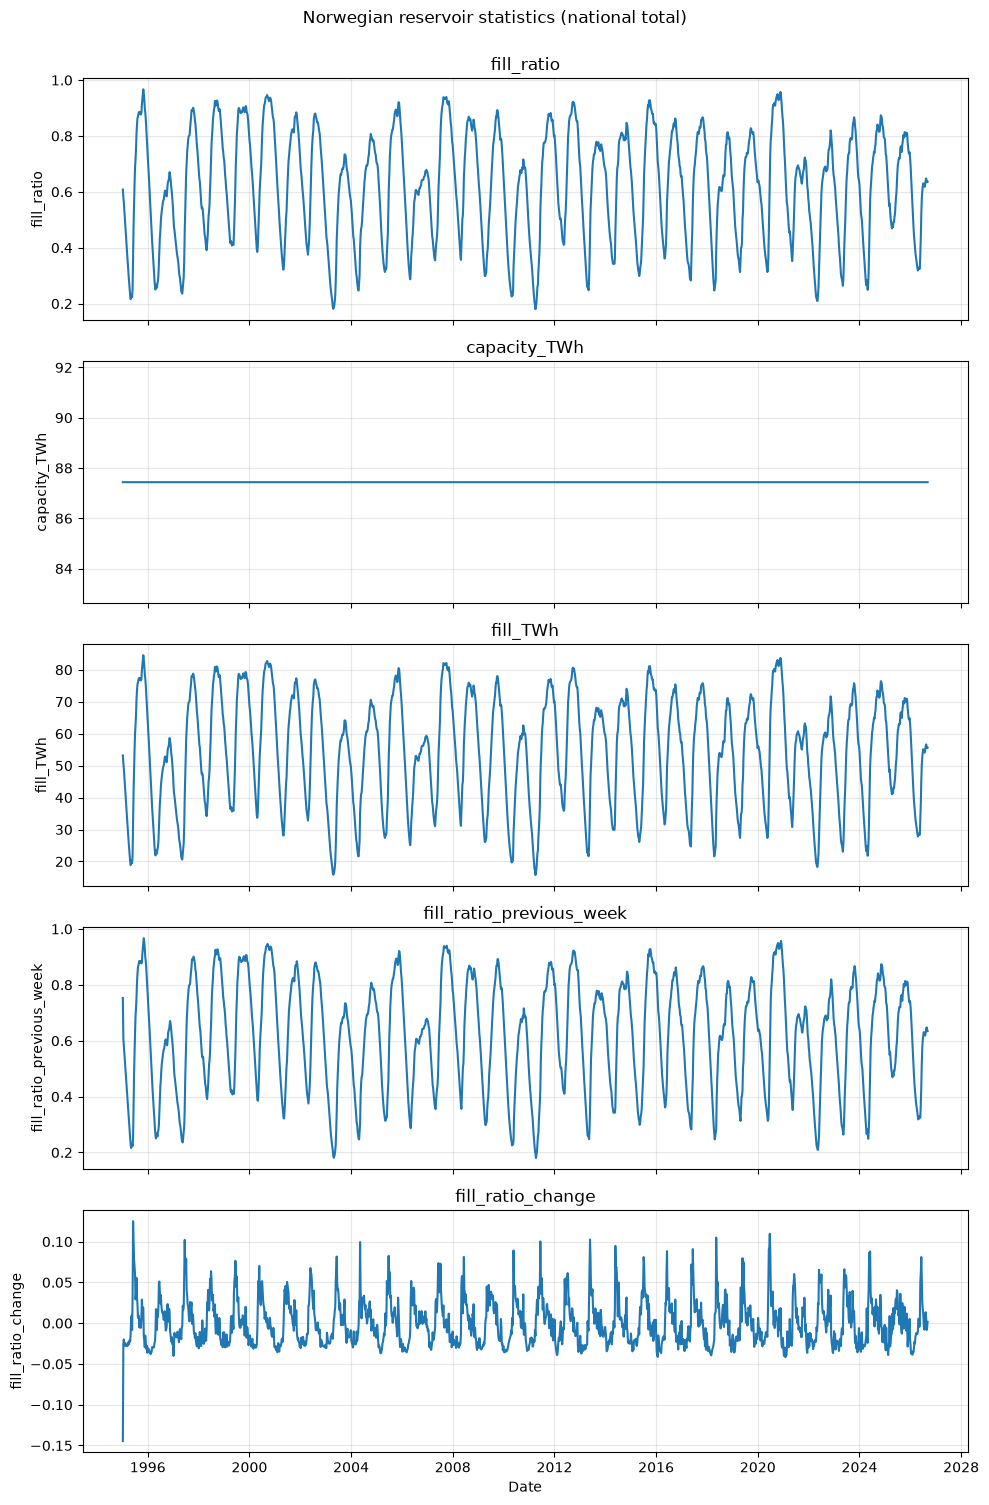

In [11]:
fig, axes = plt.subplots(len(data_columns), 1, figsize=(10, 3 * len(data_columns)), sharex=True)

for ax, column in zip(axes, data_columns):
    ax.plot(df_national["date"], df_national[column])
    ax.set_ylabel(column)
    ax.set_title(column)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle("Norwegian reservoir statistics (national total)", y=1.0)
fig.tight_layout()
plt.show()

11. Plotting all columns together

The columns are on very different scales (fill_ratio is a fraction 0-1, fill_TWh is
tens of TWh, fill_ratio_change is a small delta). To compare their shapes on one plot,
we min-max normalise each column to 0-1. capacity_TWh is excluded here since it is
essentially constant (see above) and normalising a constant column divides by ~zero.

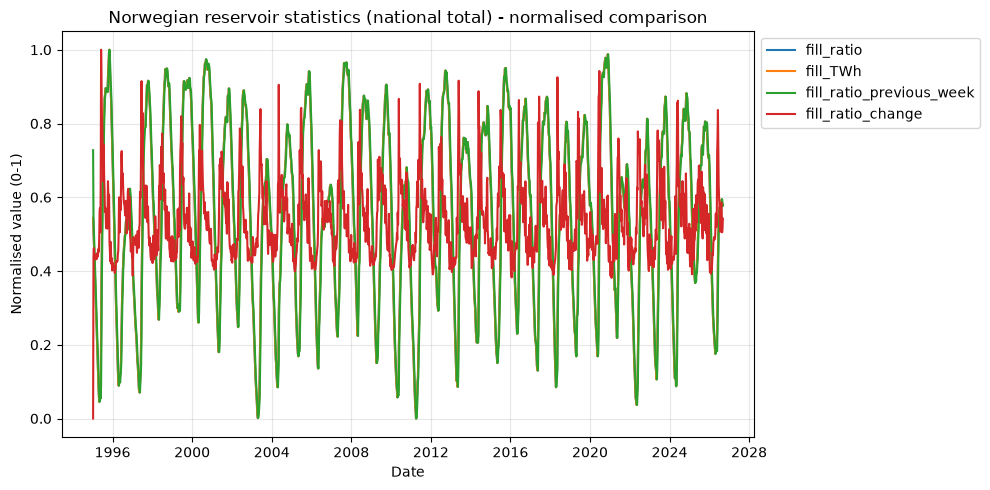

In [12]:
columns_to_compare = [c for c in data_columns if c != "capacity_TWh"]

# Min-max normalise each column to [0, 1] so they can be compared on one plot.
normalized = (df_national[columns_to_compare] - df_national[columns_to_compare].min()) / (
    df_national[columns_to_compare].max() - df_national[columns_to_compare].min()
)

fig, ax = plt.subplots(figsize=(10, 5))
for column in columns_to_compare:
    ax.plot(df_national["date"], normalized[column], label=column)

ax.set_xlabel("Date")
ax.set_ylabel("Normalised value (0-1)")
ax.set_title("Norwegian reservoir statistics (national total) - normalised comparison")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()